Model 2

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          logging, get_linear_schedule_with_warmup)
from torch.optim import AdamW

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"


# Re-seeding for consistency after constants moved.
torch.backends.cudnn.deterministic = True
torch.manual_seed(12345) # Using the constant value directly as RANDOM_STATE is in ccc462c9
np.random.seed(12345) # Using the constant value directly as RANDOM_STATE is in ccc462c9

logging.set_verbosity_error()

print(f"Environment ready. Using device: {torch.device("cuda" if torch.cuda.is_available() else "cpu")}")

Environment ready. Using device: cpu


### Refactoring: Common Utilities

To improve code organization and reduce redundancy, the following cell consolidates common imports, helper classes, and utility functions that are used across multiple model training sections. This includes the `TextPreprocessor`, data loading, data augmentation, custom `SentimentDataset`, and model training/evaluation helper functions.

In [ ]:
import random
import time
import re
import nltk
import emoji
import contractions
import torch.nn as nn
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np
import torch # Ensure torch is imported for DEVICE

# Ensure NLTK data is downloaded if not already
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

BASE_PATH = '/content/drive/MyDrive/Systement analysis/'
RANDOM_STATE = 12345
BATCH_SIZE = 16 # Reduced to alleviate memory issues
MAX_LEN = 64 # Reduced to alleviate memory issues
NUM_EPOCHS = 5
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 500
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = ['negative', 'neutral', 'positive']
num_labels = len(class_names)

# --- Helper Class: TextPreprocessor ---
class TextPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def clean_text(self, text):
        text = text.lower()  # Lowercase
        text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)  # Remove URLs
        text = re.sub(r"@\w+", "", text)  # Remove mentions
        text = emoji.demojize(text)  # Demojize
        text = contractions.fix(text)  # Fix contractions
        text = re.sub(r"[^\w\s]", "", text)  # Remove special characters
        # Filter out stopwords and lemmatize
        text = ' '.join([self.lemmatizer.lemmatize(word) for word in text.split() if word not in self.stop_words])
        return text

# Helper Function: load_project_data
def load_project_data():
    # BASE_PATH, RANDOM_STATE are now defined directly in this cell.
    train_df = pd.read_csv(BASE_PATH + 'SA_train_cleaned.csv')
    test_df = pd.read_csv(BASE_PATH + 'SA_test_cleaned.csv')

    label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    train_df['sentiment_idx'] = train_df['sentiment'].map(label_map)

    tp = TextPreprocessor()
    train_df['cleaned_text'] = train_df['text'].apply(tp.clean_text)
    test_df['cleaned_text'] = test_df['text'].apply(tp.clean_text)

    train_data_raw, val_data_raw = train_test_split(
        train_df,
        test_size=0.1,
        stratify=train_df['sentiment_idx'],
        random_state=RANDOM_STATE
    )
    return train_data_raw, val_data_raw, test_df

_STOP_WORDS = set(stopwords.words('english')) # Defined here for synonym_replacement

def synonym_replacement(words, n_aug=1):
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in _STOP_WORDS]))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = []
        for syn in wordnet.synsets(random_word):
            for lemma in syn.lemmas():
                synonym = lemma.name().replace("_", " ")
                synonyms.append(synonym)

        if len(synonyms) > 0:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1

        if num_replaced >= n_aug:
            break
    return new_words

def augment_text_data(df, augment_ratio=0.1, n_aug=1):
    augmented_data = []
    for index, row in df.iterrows():
        text = row['cleaned_text']
        sentiment = row['sentiment_idx']
        augmented_data.append({'cleaned_text': text, 'sentiment_idx': sentiment})
        if random.uniform(0, 1) < augment_ratio:
            for _ in range(n_aug):
                words = text.split()
                augmented_words = synonym_replacement(words)
                augmented_text = ' '.join(augmented_words)
                augmented_data.append({'cleaned_text': augmented_text, 'sentiment_idx': sentiment})
    return pd.DataFrame(augmented_data)

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(value[idx])
                for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def acc_score(model, dataloader, device=None):
    if device is None:
        device = DEVICE
    model.eval()
    correct_predictions, num_examples = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs
            _, predicted_labels = torch.max(logits, dim=1)
            num_examples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()
    final_accuracy = correct_predictions / num_examples
    return final_accuracy

def train_high_accuracy_model(model, train_loader, val_loader, epochs, model_save_path, optimizer_local, scheduler_local, loss_fn_local):
    best_acc = 0
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer_local.zero_grad()

            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(input_ids, attention_mask=mask)
            loss = loss_fn_local(outputs.logits, labels) # Use loss_fn_local

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Prevents exploding gradients
            optimizer_local.step()
            scheduler_local.step()

            total_loss += loss.item()

        # Validation Phase
        val_acc = acc_score(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

        # Save Best Model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            print(f"⭐ New Best Accuracy Reached!")

    print(f"\nTraining Complete. Total Time: {(time.time()-start_time)/60:.2f} min")
    return model

def evaluate_test(model, dataloader, device=None):
    if device is None:
        device = DEVICE
    model.eval()
    correct_preds, num_examples = 0, 0
    test_predictions = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs
            predicted_labels_batch = torch.argmax(logits, dim=1)
            test_predictions.append(predicted_labels_batch.cpu())
            num_examples += labels.size(0)
            correct_preds += (predicted_labels_batch == labels).sum().cpu().item()
    test_accuracy_score = correct_preds / num_examples
    test_predictions_tensor = torch.cat(test_predictions)
    return test_accuracy_score, test_predictions_tensor

In [4]:
print(f"Device used: {DEVICE}")

Device used: cpu


In [5]:
# Call the globally defined load_project_data function
train_data, val_data, test_df = load_project_data()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           66 non-null     float64
 1   Month          67 non-null     int64  
 2   Day            67 non-null     int64  
 3   date           66 non-null     object 
 4   Time of Tweet  67 non-null     object 
 5   text           67 non-null     object 
 6   sentiment      0 non-null      float64
 7   Platform       67 non-null     object 
 8   word_count     67 non-null     int64  
 9   flag_short     67 non-null     bool   
 10  text_raw       67 non-null     object 
 11  cleaned_text   67 non-null     object 
dtypes: bool(1), float64(2), int64(3), object(6)
memory usage: 6.0+ KB


### Data Augmentation: Synonym Replacement

To combat the small dataset size and improve the model's generalization capabilities, we will apply **Synonym Replacement** to our training data. This technique randomly replaces a certain percentage of words in a sentence with their synonyms, effectively generating new, slightly varied training examples.

In [6]:
# The imports for random, wordnet, stopwords, and the functions synonym_replacement and augment_text_data
# are now defined globally in the Refactoring: Common Utilities cell (ccc462c9).
# We will reuse the global definitions here.

# Apply augmentation to the training data using the globally defined function
# Note: This will increase the size of your training data. Adjust augment_ratio as needed.
augmented_train_df = augment_text_data(train_data, augment_ratio=0.5, n_aug=1)

print(f"Original training data size: {len(train_data)}")
print(f"Augmented training data size: {len(augmented_train_df)}")

# Update train_data with the augmented DataFrame
train_data = augmented_train_df

# Re-extract texts and labels from the augmented training data
training_texts = train_data["cleaned_text"].values.astype("U")
training_labels = train_data["sentiment_idx"].values

print("Training data augmented and re-initialized.")

Original training data size: 293
Augmented training data size: 439
Training data augmented and re-initialized.


**Data Exploration**

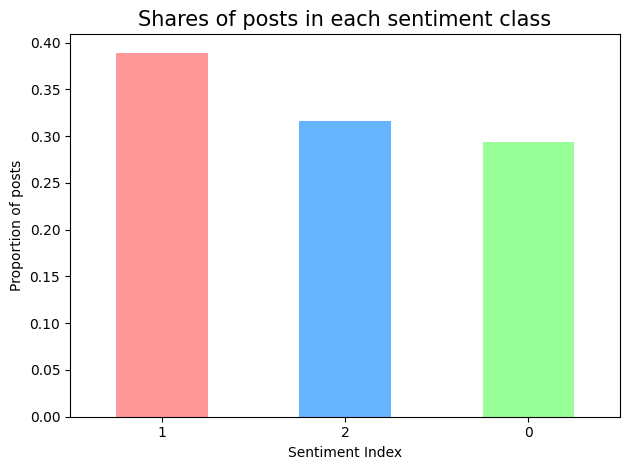

In [7]:
import matplotlib.pyplot as plt

# Phase 1: Data Analysis - Visualizing the Distribution of Sentiments
sentiment_shares = train_data["sentiment_idx"].value_counts(normalize=True)

sentiment_shares = sentiment_shares.sort_values(ascending=False)

sentiment_shares.plot(kind="bar", color=['#ff9999','#66b3ff','#99ff99'])

plt.title("Shares of posts in each sentiment class", fontsize=15)
plt.ylabel("Proportion of posts")
plt.xlabel("Sentiment Index") # Changed label to reflect sentiment_idx

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("sentiment_distribution.png")

In [8]:
# Retrieving the text data (ensuring it's string type 'U')
texts_data = train_data["cleaned_text"].values.astype("U")

labels_data = train_data["sentiment_idx"].values

**Encoding labels**

In [9]:
from sklearn.preprocessing import LabelEncoder

# The 'sentiment' column no longer exists in train_data after augmentation.
# The 'sentiment_idx' column already contains numerical labels (0, 1, 2).
# We will use these directly for labels_data_encoded.
labels_data_encoded = train_data["sentiment_idx"].values

# The 'class_names' variable is already correctly defined in the global scope
# (from the Refactoring: Common Utilities cell ccc462c9).

print("SENTIMENT ENCODING RESULTS")
for idx, class_name in enumerate(class_names):
    print(f"Index {idx:<2} => {class_name}")

# This line is harmlessly redundant as labels_data_encoded is already derived
# from train_data['sentiment_idx'], but we'll keep it as it doesn't cause issues.
train_data['sentiment_idx'] = labels_data_encoded

SENTIMENT ENCODING RESULTS
Index 0  => negative
Index 1  => neutral
Index 2  => positive


**Splitting Data**

In [10]:
from sklearn.model_selection import train_test_split

# 1. Separating data into training set (80%) and a temporary validation/test set (20%)
(training_texts_split, validation_testing_texts,
 training_labels_split, validation_testing_labels) = train_test_split(
    training_texts, # Corrected from texts_data
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded  # Ensures 3-class balance in training
)

# Rename the output variables to match common usage after the first split
training_texts = training_texts_split
training_labels = training_labels_split

# 2. Separating the 20% into validation and testing sets (10% each of total data)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels  # Ensures 3-class balance in val/test
)

# --- Statistical Justification: Data Distribution ---
print(f"Training set size:   {len(training_texts)} samples")
print(f"Validation set size: {len(validation_texts)} samples")
print(f"Testing set size:    {len(testing_texts)} samples")

Training set size:   351 samples
Validation set size: 44 samples
Testing set size:    44 samples


In [11]:
# Verifying the correctness of dimensions
assert (
    training_texts.shape[0] + validation_texts.shape[0] + testing_texts.shape[0] \
    == train_data.shape[0]
)

# Displaying the number of objects in each set
training_texts.shape[0], validation_texts.shape[0], testing_texts.shape[0]

(351, 44, 44)

**Data** **vizualization**

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_target_structure(labels, fig_title="Sentiment Distribution"):
    """
    Plotting the shares of Dataset labels (Negative, Neutral, Positive).
    """
    # Computing the number of objects within each class
    labels_count = np.bincount(labels)
    n_obj = labels.shape[0]

    # Creating a series with class names (from our label_encoder)
    labels_info_share = pd.Series(
        labels_count,
        index=class_names # Changed from label_encoder.classes_ for global access
    ) / n_obj

    labels_info_share = labels_info_share.sort_values(ascending=False)

    # Plotting the figure
    plt.figure(figsize=(8, 6))
    # Using specific colors for the psychologist's report
    colors = ['#66b3ff' if x == 'neutral' else '#ff9999' if x == 'negative' else '#99ff99' for x in labels_info_share.index]

    labels_info_share.plot(kind="bar", color=colors)

    plt.title(fig_title, fontsize=15)
    plt.xlabel("Sentiment Class")
    plt.ylabel("Proportion of Posts")

    # or 45 degrees if they are full words
    plt.xticks(rotation=0)

    plt.tight_layout()

    # Save the figure to your directory for the report
    filename = fig_title.lower().replace(" ", "_") + ".png"
    plt.savefig(filename)
    print(f"Chart saved as {filename}")

Chart saved as training_set_sentiment_structure.png
Chart saved as validation_set_sentiment_structure.png
Chart saved as testing_set_sentiment_structure.png


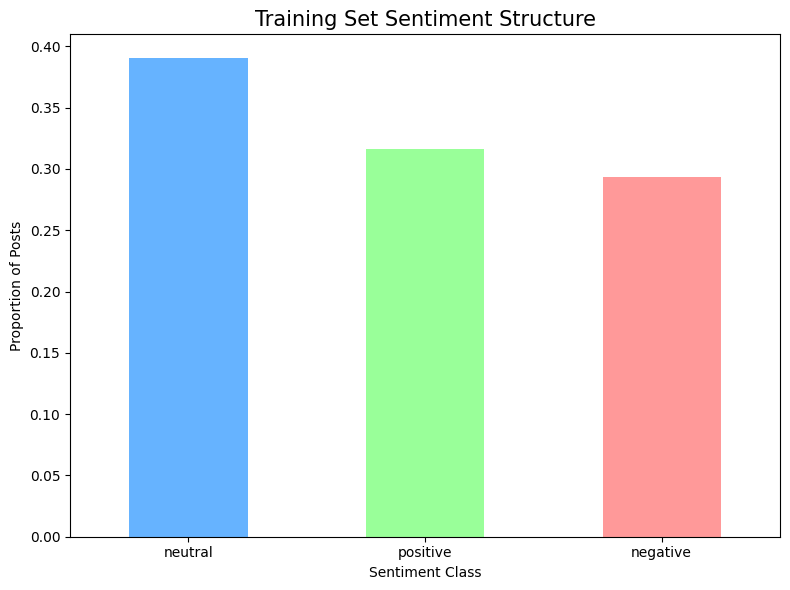

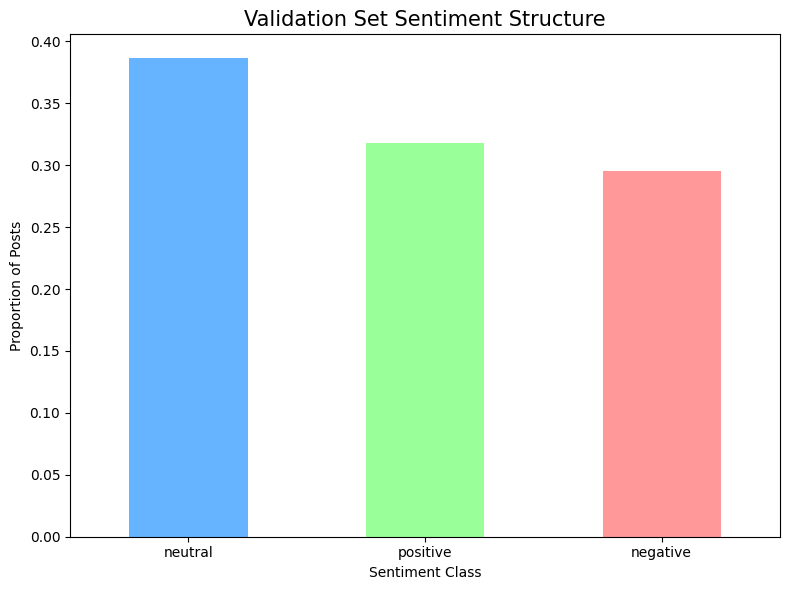

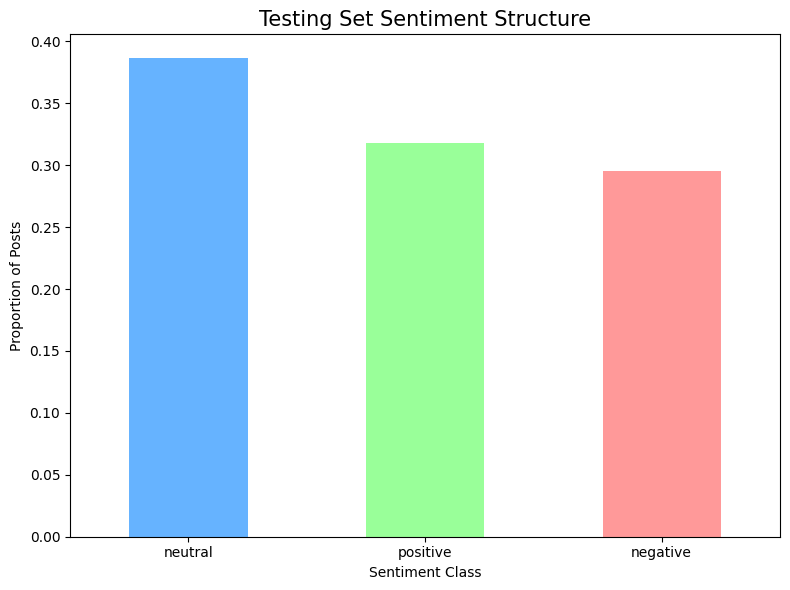

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Redefine the function with the fix, as per the constraint to modify ONLY this cell
def plot_target_structure(labels, fig_title="Sentiment Distribution"):
    """
    Plotting the shares of Dataset labels (Negative, Neutral, Positive).
    """
    # Computing the number of objects within each class
    labels_count = np.bincount(labels)
    n_obj = labels.shape[0]

    # Creating a series with class names. Use the global 'class_names' array.
    labels_info_share = pd.Series(
        labels_count,
        index=class_names # Changed from label_encoder.classes_
    ) / n_obj

    labels_info_share = labels_info_share.sort_values(ascending=False)

    # Plotting the figure
    plt.figure(figsize=(8, 6))
    # Using specific colors for the psychologist's report
    colors = ['#66b3ff' if x == 'neutral' else '#ff9999' if x == 'negative' else '#99ff99' for x in labels_info_share.index]

    labels_info_share.plot(kind="bar", color=colors)

    plt.title(fig_title, fontsize=15)
    plt.xlabel("Sentiment Class")
    plt.ylabel("Proportion of Posts")

    # or 45 degrees if they are full words
    plt.xticks(rotation=0)

    plt.tight_layout()

    # Save the figure to your directory for the report
    filename = fig_title.lower().replace(" ", "_") + ".png"
    plt.savefig(filename)
    print(f"Chart saved as {filename}")

# Check Training Set
plot_target_structure(training_labels, fig_title="Training Set Sentiment Structure")

# Check Validation Set
plot_target_structure(validation_labels, fig_title="Validation Set Sentiment Structure")

# Check Testing Set
plot_target_structure(testing_labels, fig_title="Testing Set Sentiment Structure")

**Tokenization**

In [14]:
from transformers import AutoTokenizer

# Using AutoTokenizer ensures it perfectly matches the model's expected vocabulary
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# We use list(training_texts) to ensure the input is a list of strings
training_encodings = tokenizer(
    list(training_texts),
    add_special_tokens=True,    # Adds <s> and </s> for RoBERTa
    max_length=MAX_LEN,         # We use the constant 128 defined earlier
    truncation=True,            # Cuts off text longer than 128 tokens
    padding="max_length",       # Makes all vectors the same length by adding zeros
    return_attention_mask=True
)

# 3. Tokenizing the validation examples
validation_encodings = tokenizer(
    list(validation_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)

# 4. Tokenizing the testing examples (for Phase 2 Statistical Justification)
testing_encodings = tokenizer(
    list(testing_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)

print(f"Tokenization complete for {len(training_texts)} training samples.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenization complete for 351 training samples.


In [15]:
def display_encodings_info(tokenizer, encodings, texts, labels, text_idx):
    """
    Shows the original text, its assigned sentiment,
    and how the model 'sees' it (encoded vs decoded).
    """
    text = texts[text_idx]
    print(f"--- Original Post ---\n{text}\n")

    # We use the index to find the string name (Negative, Neutral, Positive)
    sentiment_label_idx = labels[text_idx]
    sentiment_name = class_names[sentiment_label_idx]
    print(f"Target Sentiment: {sentiment_name.upper()}\n")

    # 3. Displaying the encoded text (Numerical IDs for the Model)
    text_encoded = encodings["input_ids"][text_idx]
    print(f"Encoded Input IDs (Numerical):\n{text_encoded}\n")

    # This helps you see if special characters or emojis were handled correctly
    tokens_decoded = tokenizer.convert_ids_to_tokens(text_encoded)
    print(f"Decoded Tokens (Sub-words):\n{tokens_decoded}")

In [16]:
sample_idx = 10  # Changed from 990 to 10 for safety if using the small sample

display_encodings_info(
    tokenizer=tokenizer,           # Matches our instantiated tokenizer
    encodings=training_encodings,  # The training dictionary
    texts=training_texts,          # The original text array
    labels=training_labels,        # The numerical sentiment indices
    text_idx=sample_idx            # The index you want to inspect
)

--- Original Post ---
mcfly gig last nightt oh god amazin sit whole thing mcfly see best mate tutu

Target Sentiment: POSITIVE

Encoded Input IDs (Numerical):
[0, 347, 238, 35121, 158020, 4568, 17431, 18, 13505, 2355, 2527, 7299, 1661, 28271, 13580, 347, 238, 35121, 1957, 2965, 29968, 370, 458, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Decoded Tokens (Sub-words):
['<s>', '▁m', 'c', 'fly', '▁gig', '▁last', '▁night', 't', '▁oh', '▁god', '▁ama', 'zin', '▁sit', '▁whole', '▁thing', '▁m', 'c', 'fly', '▁see', '▁best', '▁mate', '▁tu', 'tu', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [17]:
val_sample_idx = 0  # Adjusted to 0 for safety; change to 1033 for full dataset

display_encodings_info(
    tokenizer=tokenizer,             # Our project's tokenizer
    encodings=validation_encodings,  # The validation encoding dictionary
    texts=validation_texts,          # The validation text array
    labels=validation_labels,        # The numerical validation labels
    text_idx=val_sample_idx          # The specific index to inspect
)

--- Original Post ---
cannot believe went got boba without

Target Sentiment: NEUTRAL

Encoded Input IDs (Numerical):
[0, 53418, 18822, 23409, 4163, 337, 402, 15490, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Decoded Tokens (Sub-words):
['<s>', '▁cannot', '▁believe', '▁went', '▁got', '▁bo', 'ba', '▁without', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [18]:
test_sample_idx = 0  # Adjusted to 0 for safety; change to 1010 for full dataset

display_encodings_info(
    tokenizer=tokenizer,           # Our project's tokenizer
    encodings=testing_encodings,  # The testing encoding dictionary
    texts=testing_texts,          # The testing text array (unseen by model)
    labels=testing_labels,        # The ground-truth testing labels
    text_idx=test_sample_idx       # The specific index to inspect
)

--- Original Post ---
need roue negative

Target Sentiment: NEUTRAL

Encoded Input IDs (Numerical):
[0, 3871, 22629, 13, 40907, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Decoded Tokens (Sub-words):
['<s>', '▁need', '▁rou', 'e', '▁negative', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


Creating Datasets and Dataloaders

In [19]:
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    """
    Custom Dataset class for packaging tokenized sentiment data.
    This bridge allows the DataLoader to feed batches into the model.
    """

    def __init__(self, encodings, labels):
        """
        Constructor for SentimentDataset.
        Args:
            encodings: The dictionary of tensors (input_ids, attention_mask)
                       generated by the tokenizer.
            labels: The array of numerical sentiment indices (0, 1, 2).
        """
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        """Returns the total number of posts in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Returns a single sample from the dataset at the given index.
        """
        # Convert encoding values (input_ids, attention_mask) to tensors
        item = {key: torch.tensor(value[idx])
                for key, value in self.encodings.items()}

        # Adding the sentiment label as a Long tensor (required for classification)
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

train_dataset = SentimentDataset(training_encodings, training_labels)
val_dataset = SentimentDataset(validation_encodings, validation_labels)
test_dataset = SentimentDataset(testing_encodings, testing_labels)

print(f"Datasets successfully created and ready for DataLoader.")

Datasets successfully created and ready for DataLoader.


In [20]:
from torch.utils.data import DataLoader

# 1. Initializing the Sentiment Datasets (using the updated class name)
train_dataset = SentimentDataset(
    encodings=training_encodings,
    labels=training_labels
)

val_dataset = SentimentDataset(
    encodings=validation_encodings,
    labels=validation_labels
)

test_dataset = SentimentDataset(
    encodings=testing_encodings,
    labels=testing_labels
)

training_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

testing_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"DataLoaders successfully initialized with batch size: {BATCH_SIZE}")

DataLoaders successfully initialized with batch size: 16


In [21]:
# Data Scaling & Batching Report

print(f"TRAINING SET")
print(f"Examples: {len(training_dataloader.dataset):,}")
print(f"Batches:  {len(training_dataloader)}")
print(f"Batch size: {BATCH_SIZE}\n")

print(f"VALIDATION SET")
print(f"Examples: {len(validation_dataloader.dataset):,}")
print(f"Batches:  {len(validation_dataloader)}")
print(f"Batch size: {BATCH_SIZE}\n")

print(f"TESTING SET")
print(f"Examples: {len(testing_dataloader.dataset):,}")
print(f"Batches:  {len(testing_dataloader)}")
print(f"Batch size: {BATCH_SIZE}")

TRAINING SET
Examples: 351
Batches:  22
Batch size: 16

VALIDATION SET
Examples: 44
Batches:  3
Batch size: 16

TESTING SET
Examples: 44
Batches:  3
Batch size: 16


**Defining  model**

In [22]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Computing the number of classes (3: Negative, Neutral, Positive)
num_labels = len(class_names)

print(f"Initializing {MODEL_NAME} for {num_labels}-class sentiment...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

model.train()

print("Model initialized and moved to DEVICE. Optimizer set to AdamW.")

Initializing cardiffnlp/twitter-xlm-roberta-base-sentiment for 3-class sentiment...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model initialized and moved to DEVICE. Optimizer set to AdamW.


In [23]:
from transformers import get_linear_schedule_with_warmup

# Calculate total training steps
total_steps = len(training_dataloader) * NUM_EPOCHS

# Create the learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"Scheduler initialized with {total_steps} training steps and {int(0.1 * total_steps)} warmup steps.")

Scheduler initialized with 115 training steps and 11 warmup steps.


In [24]:
#Defining the BERT model
# Computing the number of classes
#num_labels = len(class_names)

#'''# Instantiating the BERT model
#bert_model = AutoModelForSequenceClassification.from_pretrained(
   # MODEL_NAME, num_labels=num_labels
#)'''

#from transformers import BertConfig, AutoModel
#config = BertConfig.from_pretrained(MODEL_NAME, num_labels=num_labels)
#bert_model =  AutoModelForSequenceClassification.from_config(config)

# Moving the model to DEVICE (GPU/CUDA)
#bert_model.to(DEVICE)

# Defining the optimization algorithm
#optimizer = torch.optim.Adam(bert_model.parameters(), lr=LEARNING_RATE)
#bert_model.eval()

In [25]:
# The acc_score function is now defined globally in the Refactoring: Common Utilities cell (ccc462c9).
# Its content has been removed from this cell to avoid duplication.


**Fine-tuning loop**

In [26]:
# The train_high_accuracy_model function is now defined globally in the Refactoring: Common Utilities cell (ccc462c9).
# Its content has been removed from this cell to avoid duplication.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 0.8504 | Val Acc: 0.6818
⭐ New Best Accuracy Reached!
Epoch 2/5 | Loss: 0.6646 | Val Acc: 0.7273
⭐ New Best Accuracy Reached!
Epoch 3/5 | Loss: 0.5853 | Val Acc: 0.7727
⭐ New Best Accuracy Reached!
Epoch 4/5 | Loss: 0.5057 | Val Acc: 0.7727
Epoch 5/5 | Loss: 0.4549 | Val Acc: 0.7727

Training Complete. Total Time: 35.57 min

FINAL TEST ACCURACY (RoBERTa): 77.2727%
              precision    recall  f1-score   support

    negative       0.79      0.85      0.81        13
     neutral       0.80      0.71      0.75        17
    positive       0.73      0.79      0.76        14

    accuracy                           0.77        44
   macro avg       0.77      0.78      0.77        44
weighted avg       0.77      0.77      0.77        44



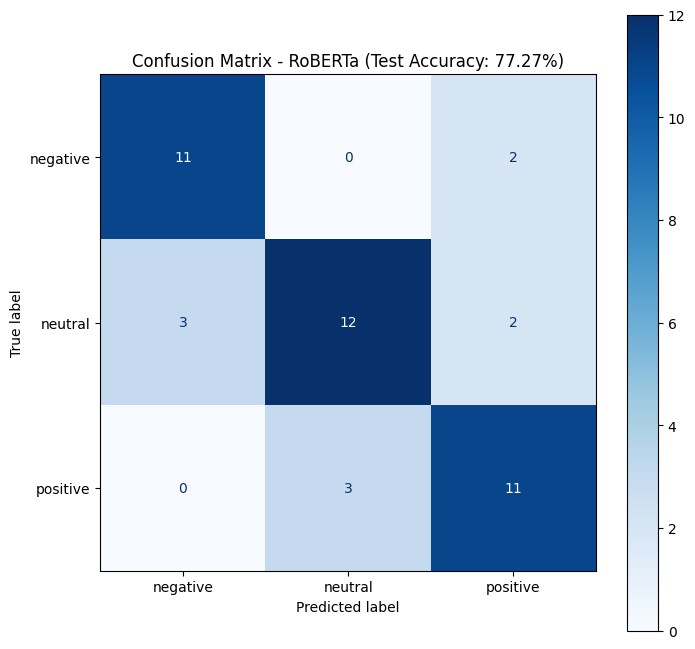

In [27]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup, AutoConfig
from torch.optim import AdamW


MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment" # This is for RoBERTa

# Load and preprocess original data
train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting (using global constants and functions)
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# Tokenization (using global constants)
tokenizer_roberta = AutoTokenizer.from_pretrained(MODEL_NAME)

training_encodings = tokenizer_roberta(
    list(training_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
validation_encodings = tokenizer_roberta(
    list(validation_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
testing_encodings = tokenizer_roberta(
    list(testing_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)

train_dataset = SentimentDataset(training_encodings, training_labels)
val_dataset = SentimentDataset(validation_encodings, validation_labels)
test_dataset = SentimentDataset(testing_encodings, testing_labels)

training_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

testing_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# --- Model Initialization for RoBERTa (using global constants) ---
config_roberta = AutoConfig.from_pretrained(MODEL_NAME)
config_roberta.num_labels = num_labels

model_roberta = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config_roberta,
    ignore_mismatched_sizes=True
)
model_roberta.float() # Ensure float32
model_roberta.to(DEVICE)

# Instantiate a new optimizer and scheduler for this model
optimizer_roberta = AdamW(model_roberta.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps_roberta = len(training_dataloader) * NUM_EPOCHS
scheduler_roberta = get_linear_schedule_with_warmup(
    optimizer_roberta,
    num_warmup_steps=int(0.1 * total_steps_roberta),
    num_training_steps=total_steps_roberta
)

# CLASS WEIGHTS (Statistical Balancing)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_labels),
    y=training_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

# Define unique save path for the current model
roberta_model_save_path = BASE_PATH + 'roberta_sentiment_model_best.pth'

trained_model_roberta = train_high_accuracy_model(model_roberta, training_dataloader, validation_dataloader, NUM_EPOCHS, roberta_model_save_path, optimizer_roberta, scheduler_roberta, loss_fn) # Pass optimizer, scheduler, and loss_fn

model_roberta.load_state_dict(torch.load(roberta_model_save_path)) # Load the best model
test_acc_roberta, test_preds_roberta = evaluate_test(trained_model_roberta, testing_dataloader)
print(f"\nFINAL TEST ACCURACY (RoBERTa): {test_acc_roberta:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

roberta_classification_report = classification_report(testing_labels, test_preds_roberta, target_names=class_names, output_dict=True) # Capture as dict
print(classification_report(testing_labels, test_preds_roberta, target_names=class_names))

all_model_results[MODEL_NAME] = {
    'accuracy': test_acc_roberta,
    'classification_report': roberta_classification_report
}

cm_roberta = confusion_matrix(testing_labels, test_preds_roberta)
disp_roberta = ConfusionMatrixDisplay(confusion_matrix=cm_roberta, display_labels=class_names)

fig_roberta, ax_roberta = plt.subplots(figsize=(8, 8))
disp_roberta.plot(cmap=plt.cm.Blues, ax=ax_roberta)
plt.title(f'Confusion Matrix - RoBERTa (Test Accuracy: {test_acc_roberta:.2%})')
plt.show()

## Model 4: BERT Base Multilingual Uncased (for Sentiment Analysis)

---< Training BERT Base Multilingual Uncased Model >---


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 1.1028 | Val Acc: 0.3636
⭐ New Best Accuracy Reached!
Epoch 2/5 | Loss: 1.0783 | Val Acc: 0.5455
⭐ New Best Accuracy Reached!
Epoch 3/5 | Loss: 1.0180 | Val Acc: 0.5455
Epoch 4/5 | Loss: 0.9514 | Val Acc: 0.4773
Epoch 5/5 | Loss: 0.9120 | Val Acc: 0.5909
⭐ New Best Accuracy Reached!

Training Complete. Total Time: 24.34 min

FINAL TEST ACCURACY (BERT Base Multilingual): 46.6667%
              precision    recall  f1-score   support

    negative       0.57      0.62      0.59        13
     neutral       0.42      0.28      0.33        18
    positive       0.42      0.57      0.48        14

    accuracy                           0.47        45
   macro avg       0.47      0.49      0.47        45
weighted avg       0.46      0.47      0.46        45



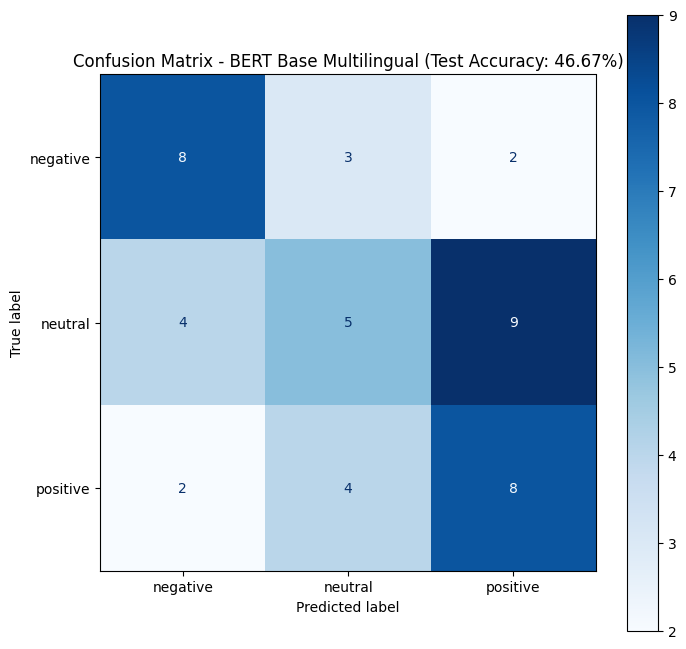

In [28]:
print("---< Training BERT Base Multilingual Uncased Model >---")
MODEL_NAME_MULTILINGUAL_BERT = "bert-base-multilingual-uncased"

# Import model-specific libraries
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn # For CrossEntropyLoss
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Load and preprocess original data
train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# Tokenization
tokenizer_multilingual_bert = AutoTokenizer.from_pretrained(MODEL_NAME_MULTILINGUAL_BERT)

training_encodings = tokenizer_multilingual_bert(
    list(training_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
validation_encodings = tokenizer_multilingual_bert(
    list(validation_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
testing_encodings = tokenizer_multilingual_bert(
    list(testing_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)

train_dataset = SentimentDataset(training_encodings, training_labels)
val_dataset = SentimentDataset(validation_encodings, validation_labels)
test_dataset = SentimentDataset(testing_encodings, testing_labels)

training_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

testing_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

config_multilingual_bert = AutoConfig.from_pretrained(MODEL_NAME_MULTILINGUAL_BERT)
config_multilingual_bert.num_labels = num_labels

model_multilingual_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_MULTILINGUAL_BERT,
    config=config_multilingual_bert,
    ignore_mismatched_sizes=True
)
model_multilingual_bert.float()
model_multilingual_bert.to(DEVICE)

# Instantiate a new optimizer and scheduler for this model
optimizer_multilingual_bert = AdamW(model_multilingual_bert.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps_multilingual_bert = len(training_dataloader) * NUM_EPOCHS
scheduler_multilingual_bert = get_linear_schedule_with_warmup(
    optimizer_multilingual_bert,
    num_warmup_steps=int(0.1 * total_steps_multilingual_bert),
    num_training_steps=total_steps_multilingual_bert
)

# CLASS WEIGHTS (Statistical Balancing)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_labels),
    y=training_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

# Define unique save path for the current model
multilingual_bert_model_save_path = BASE_PATH + 'multilingual_bert_sentiment_model_best.pth'

trained_model_multilingual_bert = train_high_accuracy_model(model_multilingual_bert, training_dataloader, validation_dataloader, NUM_EPOCHS, multilingual_bert_model_save_path, optimizer_multilingual_bert, scheduler_multilingual_bert, loss_fn)

model_multilingual_bert.load_state_dict(torch.load(multilingual_bert_model_save_path))
test_acc_multilingual_bert, test_preds_multilingual_bert = evaluate_test(trained_model_multilingual_bert, testing_dataloader)
print(f"\nFINAL TEST ACCURACY (BERT Base Multilingual): {test_acc_multilingual_bert:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

multilingual_bert_classification_report = classification_report(testing_labels, test_preds_multilingual_bert, target_names=class_names, output_dict=True)
print(classification_report(testing_labels, test_preds_multilingual_bert, target_names=class_names))

all_model_results[MODEL_NAME_MULTILINGUAL_BERT] = {
    'accuracy': test_acc_multilingual_bert,
    'classification_report': multilingual_bert_classification_report
}

cm_multilingual_bert = confusion_matrix(testing_labels, test_preds_multilingual_bert)
disp_multilingual_bert = ConfusionMatrixDisplay(confusion_matrix=cm_multilingual_bert, display_labels=class_names)
fig_multilingual_bert, ax_multilingual_bert = plt.subplots(figsize=(8, 8))
disp_multilingual_bert.plot(cmap=plt.cm.Blues, ax=ax_multilingual_bert)
plt.title(f'Confusion Matrix - BERT Base Multilingual (Test Accuracy: {test_acc_multilingual_bert:.2%})')
plt.show()

## Model 5: Support Vector Machine (SVM) with TF-IDF

Training Support Vector Machine Model

FINAL TEST ACCURACY (SVM): 72.7273%
              precision    recall  f1-score   support

    negative       0.63      0.92      0.75        13
     neutral       0.83      0.59      0.69        17
    positive       0.77      0.71      0.74        14

    accuracy                           0.73        44
   macro avg       0.74      0.74      0.73        44
weighted avg       0.75      0.73      0.72        44



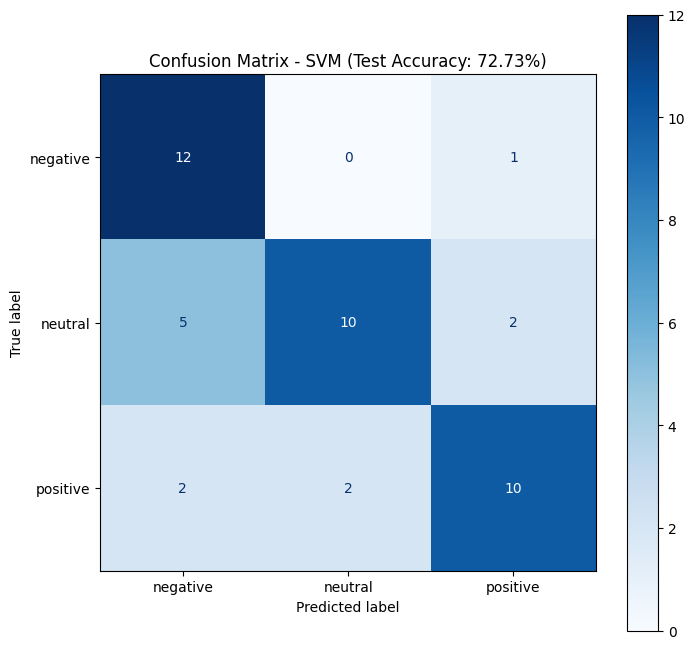

In [24]:
print("Training Support Vector Machine Model")

# Import model-specific libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load and preprocess original data
train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to manage complexity
X_train_tfidf = vectorizer.fit_transform(training_texts)
X_test_tfidf = vectorizer.transform(testing_texts)

# Initialize and Train SVM Model
svm_model = SVC(kernel='linear', random_state=RANDOM_STATE)
svm_model.fit(X_train_tfidf, training_labels)

# Evaluate SVM Model
svm_predictions = svm_model.predict(X_test_tfidf)

# Calculate accuracy
svm_test_accuracy = (svm_predictions == testing_labels).mean()
print(f"\nFINAL TEST ACCURACY (SVM): {svm_test_accuracy:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

svm_classification_report = classification_report(testing_labels, svm_predictions, target_names=class_names, output_dict=True)
print(classification_report(testing_labels, svm_predictions, target_names=class_names))

all_model_results['SVM_TFIDF'] = {
    'accuracy': svm_test_accuracy,
    'classification_report': svm_classification_report
}

# Confusion Matrix
cm_svm = confusion_matrix(testing_labels, svm_predictions)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
fig_svm, ax_svm = plt.subplots(figsize=(8, 8))
disp_svm.plot(cmap=plt.cm.Blues, ax=ax_svm)
plt.title(f'Confusion Matrix - SVM (Test Accuracy: {svm_test_accuracy:.2%})')
plt.show()

## Model 6: Logistic Regression with TF-IDF

---< Training Logistic Regression Model >---

FINAL TEST ACCURACY (Logistic Regression): 74.4186%
              precision    recall  f1-score   support

    negative       1.00      0.62      0.76        13
     neutral       0.65      0.81      0.72        16
    positive       0.73      0.79      0.76        14

    accuracy                           0.74        43
   macro avg       0.79      0.74      0.75        43
weighted avg       0.78      0.74      0.75        43



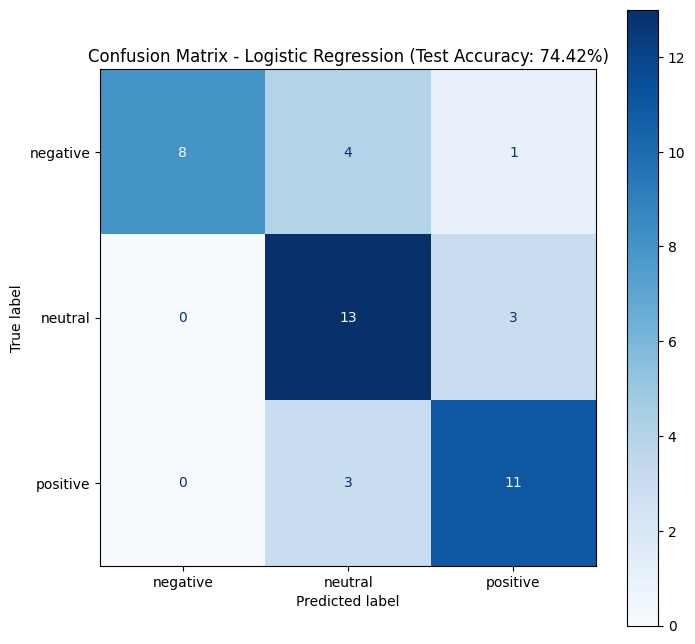

In [26]:
print("Training Logistic Regression Model")

# Import model-specific libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load and preprocess original data
train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(training_texts)
X_test_tfidf = vectorizer.transform(testing_texts)

# Initialize and Train Logistic Regression Model
logreg_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='liblinear') # Increased max_iter for convergence
logreg_model.fit(X_train_tfidf, training_labels)

# Evaluate Logistic Regression Model
logreg_predictions = logreg_model.predict(X_test_tfidf)

# Calculate accuracy
logreg_test_accuracy = (logreg_predictions == testing_labels).mean()
print(f"\nFINAL TEST ACCURACY (Logistic Regression): {logreg_test_accuracy:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

logreg_classification_report = classification_report(testing_labels, logreg_predictions, target_names=class_names, output_dict=True)
print(classification_report(testing_labels, logreg_predictions, target_names=class_names))

all_model_results['Logistic_Regression_TFIDF'] = {
    'accuracy': logreg_test_accuracy,
    'classification_report': logreg_classification_report
}

# Confusion Matrix
cm_logreg = confusion_matrix(testing_labels, logreg_predictions)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=class_names)
fig_logreg, ax_logreg = plt.subplots(figsize=(8, 8))
disp_logreg.plot(cmap=plt.cm.Blues, ax=ax_logreg)
plt.title(f'Confusion Matrix - Logistic Regression (Test Accuracy: {logreg_test_accuracy:.2%})')
plt.show()

## Model 7: Multinomial Naive Bayes with TF-IDF

Training Multinomial Naive Bayes Model

FINAL TEST ACCURACY (Multinomial Naive Bayes): 73.9130%
              precision    recall  f1-score   support

    negative       1.00      0.69      0.82        13
     neutral       0.65      0.72      0.68        18
    positive       0.71      0.80      0.75        15

    accuracy                           0.74        46
   macro avg       0.79      0.74      0.75        46
weighted avg       0.77      0.74      0.74        46



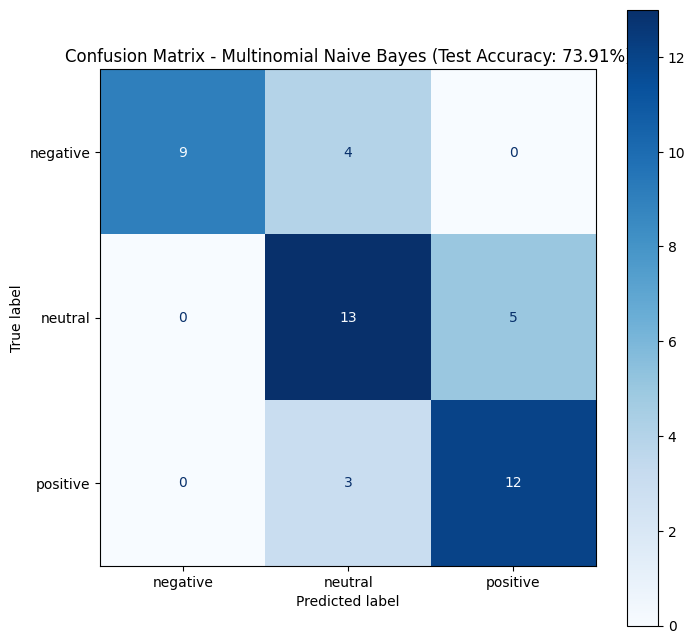

In [27]:
print("Training Multinomial Naive Bayes Model")

# Import model-specific libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load and preprocess original data
train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(training_texts)
X_test_tfidf = vectorizer.transform(testing_texts)

# Initialize and Train Multinomial Naive Bayes Model
mnb_model = MultinomialNB()
mnb_model.fit(X_train_tfidf, training_labels)

# Evaluate Multinomial Naive Bayes Model
mnb_predictions = mnb_model.predict(X_test_tfidf)

# Calculate accuracy
mnb_test_accuracy = (mnb_predictions == testing_labels).mean()
print(f"\nFINAL TEST ACCURACY (Multinomial Naive Bayes): {mnb_test_accuracy:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

mnb_classification_report = classification_report(testing_labels, mnb_predictions, target_names=class_names, output_dict=True)
print(classification_report(testing_labels, mnb_predictions, target_names=class_names))

all_model_results['Multinomial_Naive_Bayes_TFIDF'] = {
    'accuracy': mnb_test_accuracy,
    'classification_report': mnb_classification_report
}

# Confusion Matrix
cm_mnb = confusion_matrix(testing_labels, mnb_predictions)
disp_mnb = ConfusionMatrixDisplay(confusion_matrix=cm_mnb, display_labels=class_names)
fig_mnb, ax_mnb = plt.subplots(figsize=(8, 8))
disp_mnb.plot(cmap=plt.cm.Blues, ax=ax_mnb)
plt.title(f'Confusion Matrix - Multinomial Naive Bayes (Test Accuracy: {mnb_test_accuracy:.2%})')
plt.show()

## Model 2: BERT Base Uncased

Training BERT Base Uncased Model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 1.1138 | Val Acc: 0.2727
⭐ New Best Accuracy Reached!
Epoch 2/5 | Loss: 1.0825 | Val Acc: 0.4773
⭐ New Best Accuracy Reached!
Epoch 3/5 | Loss: 1.0640 | Val Acc: 0.4773
Epoch 4/5 | Loss: 1.0311 | Val Acc: 0.5455
⭐ New Best Accuracy Reached!
Epoch 5/5 | Loss: 0.9966 | Val Acc: 0.5909
⭐ New Best Accuracy Reached!

Training Complete. Total Time: 22.86 min

FINAL TEST ACCURACY (BERT): 50.0000%
              precision    recall  f1-score   support

    negative       0.50      0.17      0.25        12
     neutral       0.75      0.35      0.48        17
    positive       0.44      0.93      0.60        15

    accuracy                           0.50        44
   macro avg       0.56      0.48      0.44        44
weighted avg       0.58      0.50      0.46        44



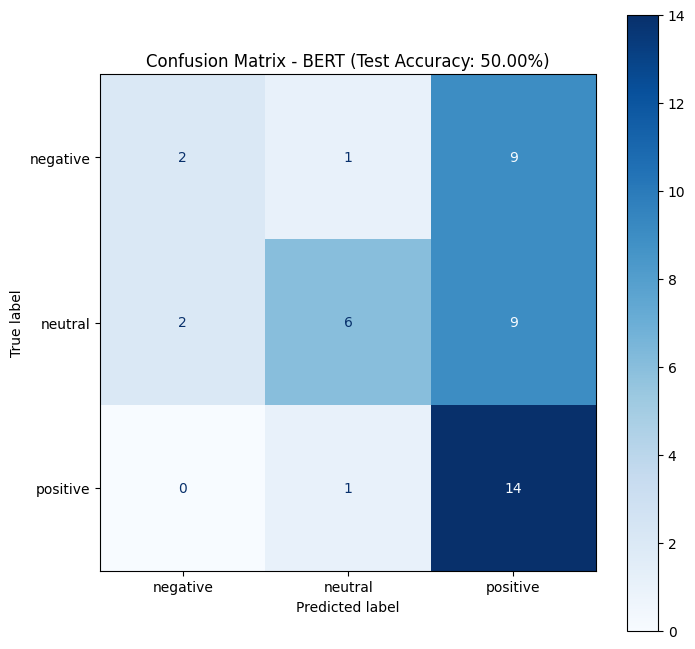

In [25]:
print("Training BERT Base Uncased Model")
MODEL_NAME_BERT = "bert-base-uncased"



from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn # For CrossEntropyLoss
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# Tokenization
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME_BERT)

training_encodings = tokenizer_bert(
    list(training_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
validation_encodings = tokenizer_bert(
    list(validation_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
testing_encodings = tokenizer_bert(
    list(testing_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)

train_dataset = SentimentDataset(training_encodings, training_labels)
val_dataset = SentimentDataset(validation_encodings, validation_labels)
test_dataset = SentimentDataset(testing_encodings, testing_labels)

training_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

testing_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

config_bert = AutoConfig.from_pretrained(MODEL_NAME_BERT)
config_bert.num_labels = num_labels # Set the number of labels in the config

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_BERT,
    config=config_bert, # Pass the modified config
    ignore_mismatched_sizes=True # Keep this for safety, though config should handle it
)
model_bert.float() # Explicitly cast model parameters to float32
model_bert.to(DEVICE)

# Instantiate a new optimizer and scheduler for this model
optimizer_bert = AdamW(model_bert.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps_bert = len(training_dataloader) * NUM_EPOCHS
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps_bert),
    num_training_steps=total_steps_bert
)

# CLASS WEIGHTS (Statistical Balancing) ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_labels),
    y=training_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

bert_model_save_path = BASE_PATH + 'bert_sentiment_model_best.pth'
trained_model_bert = train_high_accuracy_model(model_bert, training_dataloader, validation_dataloader, NUM_EPOCHS, bert_model_save_path, optimizer_bert, scheduler_bert, loss_fn)

model_bert.load_state_dict(torch.load(bert_model_save_path))
test_acc_bert, test_preds_bert = evaluate_test(trained_model_bert, testing_dataloader)
print(f"\nFINAL TEST ACCURACY (BERT): {test_acc_bert:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

bert_classification_report = classification_report(testing_labels, test_preds_bert, target_names=class_names, output_dict=True)
print(classification_report(testing_labels, test_preds_bert, target_names=class_names))

all_model_results[MODEL_NAME_BERT] = {
    'accuracy': test_acc_bert,
    'classification_report': bert_classification_report
}

cm_bert = confusion_matrix(testing_labels, test_preds_bert)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=class_names)
fig_bert, ax_bert = plt.subplots(figsize=(8, 8))
disp_bert.plot(cmap=plt.cm.Blues, ax=ax_bert)
plt.title(f'Confusion Matrix - BERT (Test Accuracy: {test_acc_bert:.2%})')
plt.show()

## Model 3: DistilBERT Base Uncased

In [ ]:
print("Training DistilBERT Base Uncased Model")
MODEL_NAME_DISTILBERT = "distilbert-base-uncased"

# Import model-specific libraries
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn # For CrossEntropyLoss
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight


train_data_original, val_data_original, test_df_unused = load_project_data()

# Apply augmentation to the training data
augmented_train_df = augment_text_data(train_data_original, augment_ratio=0.5, n_aug=1)
train_data = augmented_train_df # This is the final train_data (augmented)

# Re-extract texts and labels from the augmented training data
texts_data = train_data["cleaned_text"].values.astype("U")
labels_data_encoded = train_data["sentiment_idx"].values

# Data splitting
(training_texts, validation_testing_texts,
 training_labels, validation_testing_labels) = train_test_split(
    texts_data,
    labels_data_encoded,
    train_size=0.8,
    random_state=RANDOM_STATE,
    stratify=labels_data_encoded
)
(validation_texts, testing_texts,
 validation_labels, testing_labels) = train_test_split(
    validation_testing_texts,
    validation_testing_labels,
    train_size=0.5,
    random_state=RANDOM_STATE,
    stratify=validation_testing_labels
)

# Tokenization
tokenizer_distilbert = AutoTokenizer.from_pretrained(MODEL_NAME_DISTILBERT)

training_encodings = tokenizer_distilbert(
    list(training_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
validation_encodings = tokenizer_distilbert(
    list(validation_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)
testing_encodings = tokenizer_distilbert(
    list(testing_texts),
    add_special_tokens=True,
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length",
    return_attention_mask=True
)

# --- Dataloader Creation (using global SentimentDataset and BATCH_SIZE) ---
train_dataset = SentimentDataset(training_encodings, training_labels)
val_dataset = SentimentDataset(validation_encodings, validation_labels)
test_dataset = SentimentDataset(testing_encodings, testing_labels)

training_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

testing_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# --- Model Initialization (using global constants) ---
config_distilbert = AutoConfig.from_pretrained(MODEL_NAME_DISTILBERT)
config_distilbert.num_labels = num_labels

model_distilbert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME_DISTILBERT,
    config=config_distilbert,
    ignore_mismatched_sizes=True
)
model_distilbert.float()
model_distilbert.to(DEVICE)

# Instantiate optimizer and scheduler
optimizer_distilbert = AdamW(model_distilbert.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps_distilbert = len(training_dataloader) * NUM_EPOCHS
scheduler_distilbert = get_linear_schedule_with_warmup(
    optimizer_distilbert,
    num_warmup_steps=int(0.1 * total_steps_distilbert),
    num_training_steps=total_steps_distilbert
)

# --- Training Execution (using global functions and constants) ---
# CLASS WEIGHTS (Statistical Balancing) ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(training_labels),
    y=training_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

# Define unique save path for the current model
distilbert_model_save_path = BASE_PATH + 'distilbert_sentiment_model_best.pth'

# EXECUTION & EVALUATION
trained_model_distilbert = train_high_accuracy_model(model_distilbert, training_dataloader, validation_dataloader, NUM_EPOCHS, distilbert_model_save_path, optimizer_distilbert, scheduler_distilbert, loss_fn)

model_distilbert.load_state_dict(torch.load(distilbert_model_save_path))
test_acc_distilbert, test_preds_distilbert = evaluate_test(trained_model_distilbert, testing_dataloader)
print(f"\nFINAL TEST ACCURACY (DistilBERT): {test_acc_distilbert:.4%}")

# Ensure all_model_results is defined, if not, initialize it
if 'all_model_results' not in globals():
    all_model_results = {}

distilbert_classification_report = classification_report(testing_labels, test_preds_distilbert, target_names=class_names, output_dict=True)
print(classification_report(testing_labels, test_preds_distilbert, target_names=class_names))

all_model_results[MODEL_NAME_DISTILBERT] = {
    'accuracy': test_acc_distilbert,
    'classification_report': distilbert_classification_report
}

cm_distilbert = confusion_matrix(testing_labels, test_preds_distilbert)
disp_distilbert = ConfusionMatrixDisplay(confusion_matrix=cm_distilbert, display_labels=class_names)
fig_distilbert, ax_distilbert = plt.subplots(figsize=(8, 8))
disp_distilbert.plot(cmap=plt.cm.Blues, ax=ax_distilbert)
plt.title(f'Confusion Matrix - DistilBERT (Test Accuracy: {test_acc_distilbert:.2%})')
plt.show()

In [ ]:
# The evaluate_test function is now defined globally in the Refactoring: Common Utilities cell (ccc462c9).
# Its content has been removed from this cell to avoid duplication.
